In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import equinox as eqx
from jaxtyping import Float

import dismech_jax as djx

from util import *
from helpers import *
from animate import animate

jax.config.update("jax_enable_x64", True)

In [2]:
from Energy_NN_architectures import *

K_init = jnp.array([2.0, 0.001, 0.02])

train_data = "../data/output_old.npz"
valid_data = "../data/output_valid.npz"

train_file = "training_data.npz"
valid_file = "validation_data.npz"
# convert to direct-BC format
convert_linear_bc_to_direct_bc(train_data, train_file, lambdas=None)
convert_linear_bc_to_direct_bc(valid_data, valid_file, lambdas=None)


Saved converted direct-BC dataset to: training_data.npz
qs.shape      = (1, 11, 11)
xb.shape      = (1, 11, 8)
idx_b.shape   = (8,)
lambdas.shape = (11,)
Saved converted direct-BC dataset to: validation_data.npz
qs.shape      = (1, 11, 11)
xb.shape      = (1, 11, 8)
idx_b.shape   = (8,)
lambdas.shape = (11,)


In [3]:

final_model, train_history, valid_history = train_model(CholeskyPlusStiffnessNN, key=jax.random.PRNGKey(42), train_file=train_file, valid_file=valid_file, n_epochs=500, lr=1e-2, init_K=K_init )

Epoch 000 | Train: 1.001e-03 | Valid: 1.758e-03
Epoch 010 | Train: 9.093e-05 | Valid: 2.177e-03
Epoch 020 | Train: 2.015e-05 | Valid: 2.163e-03
Epoch 030 | Train: 9.003e-06 | Valid: 6.237e-04
Epoch 040 | Train: 7.943e-06 | Valid: 3.429e-04
Epoch 050 | Train: 6.984e-06 | Valid: 4.327e-04
Epoch 060 | Train: 6.056e-06 | Valid: 3.943e-04
Epoch 070 | Train: 5.214e-06 | Valid: 6.923e-04
Epoch 080 | Train: 4.574e-06 | Valid: 1.087e-03
Epoch 090 | Train: 4.111e-06 | Valid: 1.107e-03
Epoch 100 | Train: 3.827e-06 | Valid: 1.135e-03
Epoch 110 | Train: 3.678e-06 | Valid: 1.167e-03
Epoch 120 | Train: 3.603e-06 | Valid: 1.211e-03
Epoch 130 | Train: 3.560e-06 | Valid: 1.535e-03
Epoch 140 | Train: 3.528e-06 | Valid: 1.215e-03
Epoch 150 | Train: 3.498e-06 | Valid: 1.038e-03
Epoch 160 | Train: 3.468e-06 | Valid: 1.512e-03
Epoch 170 | Train: 3.437e-06 | Valid: 9.348e-04
Epoch 180 | Train: 3.406e-06 | Valid: 1.153e-03
Epoch 190 | Train: 3.374e-06 | Valid: 1.139e-03
Epoch 200 | Train: 3.342e-06 | Valid: 1.

500


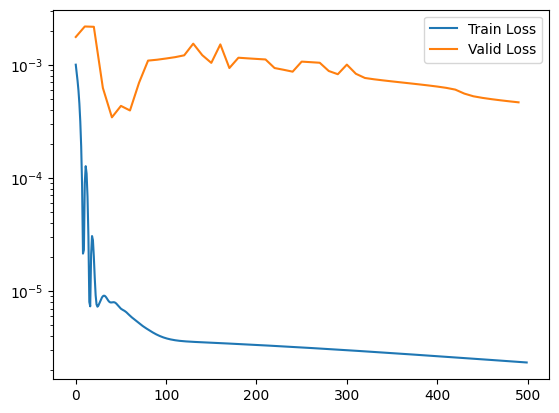

In [4]:
import matplotlib.pyplot as plt
train_np = np.asarray(train_history, dtype=float).reshape(-1)
valid_np = np.asarray(valid_history, dtype=float).reshape(-1)

print(len(train_history))

idx_valid = np.where(valid_np != -1)[0]

plt.plot(np.arange(train_np.size), train_np, label="Train Loss")
plt.plot(idx_valid, valid_np[idx_valid], label="Valid Loss")
plt.yscale("log")
plt.legend()
plt.show()